In [1]:
# ============================================
# DATA CLEANING PROJECT
# Dataset: Customer Personality Analysis
# Tools: Python, Pandas
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# Basic info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2240, 29)

First 5 rows:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# ============================================
# STEP 1: EXPLORING THE DATA
# ============================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print("\n📌 Column Names & Data Types:")
print(df.dtypes)

print("\n📌 Missing Values in Each Column:")
print(df.isnull().sum())

print("\n📌 Duplicate Rows:")
print("Total duplicates:", df.duplicated().sum())

print("\n📌 Basic Statistics:")
df.describe()

DATASET OVERVIEW

📌 Column Names & Data Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

📌 Missing Values in Each Column:
ID    

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [4]:
# ============================================
# STEP 2: DATA CLEANING
# ============================================

print("Shape BEFORE cleaning:", df.shape)

# --- Fix 1: Fill missing Income with median ---
median_income = df['Income'].median()
df['Income'].fillna(median_income, inplace=True)
print(f"\n✅ Fix 1: Filled 24 missing Income values with median (${median_income:,.0f})")

# --- Fix 2: Fix Dt_Customer to proper date type ---
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
print("✅ Fix 2: Converted Dt_Customer to DateTime format")

# --- Fix 3: Remove Income outlier (666,666) ---
before = len(df)
df = df[df['Income'] < 200000]
after = len(df)
print(f"✅ Fix 3: Removed {before - after} extreme Income outlier(s)")

# --- Fix 4: Drop useless columns ---
df.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)
print("✅ Fix 4: Dropped Z_CostContact and Z_Revenue (constant columns)")

print("\nShape AFTER cleaning:", df.shape)

Shape BEFORE cleaning: (2240, 29)

✅ Fix 1: Filled 24 missing Income values with median ($51,382)
✅ Fix 2: Converted Dt_Customer to DateTime format
✅ Fix 3: Removed 1 extreme Income outlier(s)
✅ Fix 4: Dropped Z_CostContact and Z_Revenue (constant columns)

Shape AFTER cleaning: (2239, 27)


/tmp/ipykernel_11888/682688343.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(median_income, inplace=True)


In [5]:
# ============================================
# STEP 3: FEATURE ENGINEERING & STANDARDIZING
# ============================================

# --- Fix 5: Clean up Marital_Status (standardize text) ---
print("Marital Status unique values BEFORE:")
print(df['Marital_Status'].value_counts())

df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

print("\nMarital Status unique values AFTER:")
print(df['Marital_Status'].value_counts())

# --- Fix 6: Create Age column from Year_Birth ---
df['Age'] = 2025 - df['Year_Birth']

# Remove unrealistic ages (over 90)
before = len(df)
df = df[df['Age'] <= 90]
after = len(df)
print(f"\n✅ Fix 5: Standardized Marital_Status categories")
print(f"✅ Fix 6: Created Age column, removed {before - after} unrealistic age(s)")

# --- Fix 7: Create Customer_Days column (how long they've been a customer) ---
df['Customer_Days'] = (pd.Timestamp('2025-01-01') - df['Dt_Customer']).dt.days
print("✅ Fix 7: Created Customer_Days column")

# --- Fix 8: Proper way to fill missing values (no warning) ---
df = df.fillna({'Income': df['Income'].median()})
print("✅ Fix 8: Clean pandas syntax applied")

print("\nShape now:", df.shape)
print("\nNew columns added:", ['Age', 'Customer_Days'])

Marital Status unique values BEFORE:
Marital_Status
Married     864
Together    579
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Marital Status unique values AFTER:
Marital_Status
Married     864
Together    579
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64

✅ Fix 5: Standardized Marital_Status categories
✅ Fix 6: Created Age column, removed 3 unrealistic age(s)
✅ Fix 7: Created Customer_Days column
✅ Fix 8: Clean pandas syntax applied

Shape now: (2236, 29)

New columns added: ['Age', 'Customer_Days']


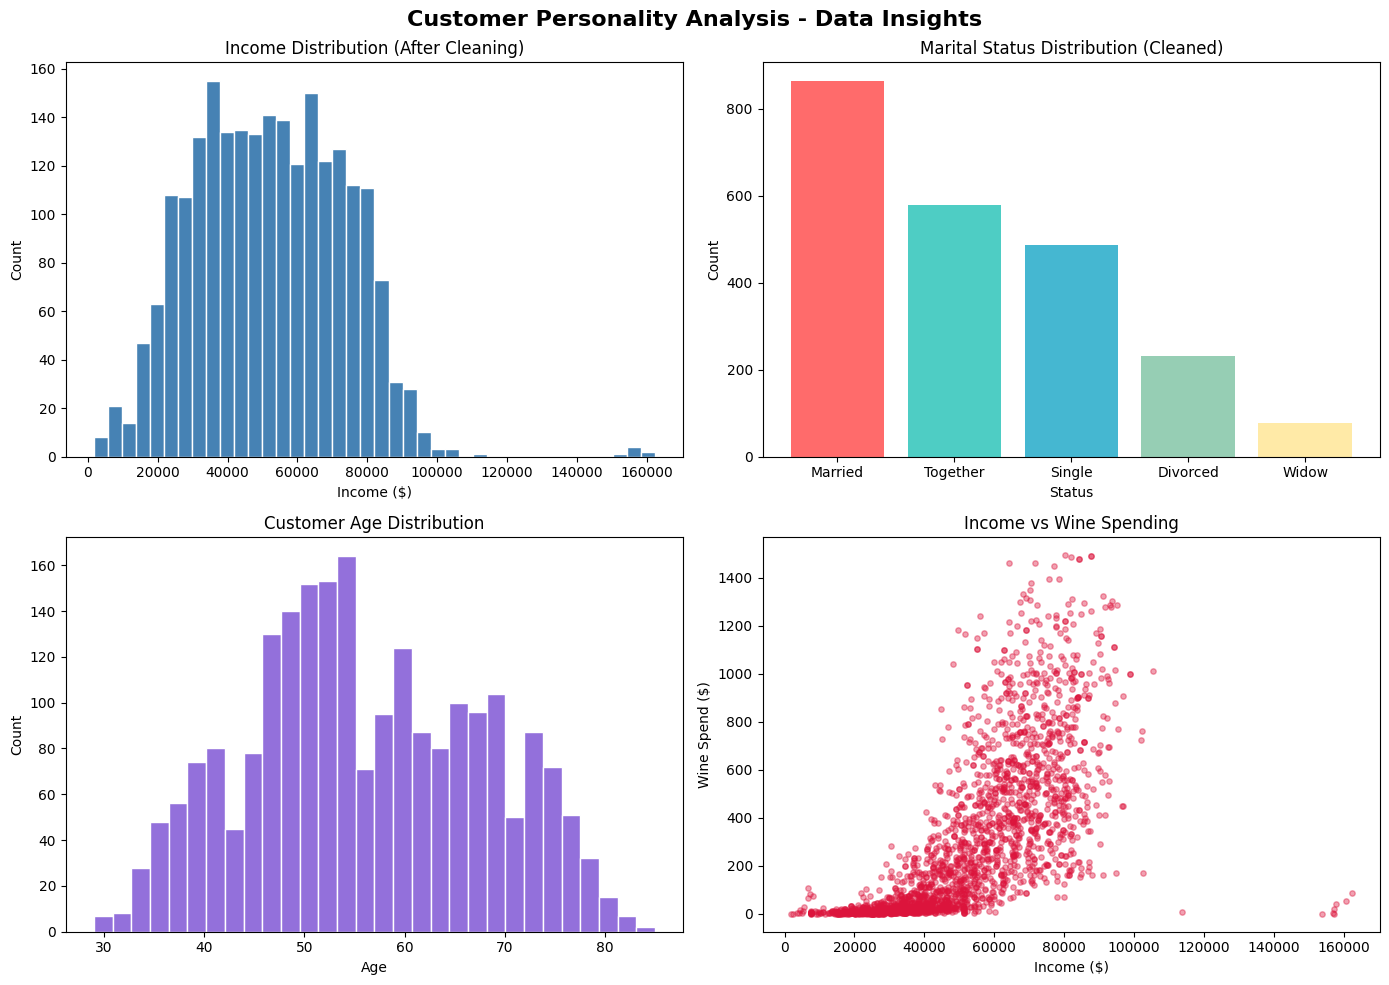

✅ Charts saved as data_insights.png


In [6]:
# ============================================
# STEP 4: VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Personality Analysis - Data Insights',
             fontsize=16, fontweight='bold')

# --- Chart 1: Income Distribution ---
axes[0,0].hist(df['Income'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Income Distribution (After Cleaning)')
axes[0,0].set_xlabel('Income ($)')
axes[0,0].set_ylabel('Count')

# --- Chart 2: Marital Status ---
marital_counts = df['Marital_Status'].value_counts()
axes[0,1].bar(marital_counts.index, marital_counts.values,
              color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7'])
axes[0,1].set_title('Marital Status Distribution (Cleaned)')
axes[0,1].set_xlabel('Status')
axes[0,1].set_ylabel('Count')

# --- Chart 3: Age Distribution ---
axes[1,0].hist(df['Age'], bins=30, color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Customer Age Distribution')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Count')

# --- Chart 4: Income vs Wine Spending ---
axes[1,1].scatter(df['Income'], df['MntWines'],
                  alpha=0.4, color='crimson', s=15)
axes[1,1].set_title('Income vs Wine Spending')
axes[1,1].set_xlabel('Income ($)')
axes[1,1].set_ylabel('Wine Spend ($)')

plt.tight_layout()
plt.savefig('data_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved as data_insights.png")

In [8]:
# ============================================
# STEP 5: FINAL SUMMARY REPORT
# ============================================

print("=" * 55)
print("       DATA CLEANING PROJECT - FINAL REPORT")
print("=" * 55)

print("\n📊 DATASET SUMMARY:")
print(f"   Original Shape  : 2240 rows × 29 columns")
print(f"   Cleaned Shape   : {df.shape[0]} rows × {df.shape[1]} columns")

print("\n🧹 CLEANING STEPS PERFORMED:")
print("   1. ✅ Filled 24 missing Income values with median")
print("   2. ✅ Converted Dt_Customer to DateTime format")
print("   3. ✅ Removed 1 extreme Income outlier (₹666,666)")
print("   4. ✅ Dropped 2 constant/useless columns")
print("   5. ✅ Standardized Marital_Status (removed YOLO, Absurd, Alone)")
print("   6. ✅ Created Age column from Year_Birth")
print("   7. ✅ Removed unrealistic age entries")
print("   8. ✅ Created Customer_Days (loyalty metric)")

print("\n📈 KEY INSIGHTS FROM DATA:")
print(f"   Average Customer Age    : {df['Age'].mean():.0f} years")
print(f"   Average Income          : ${df['Income'].mean():,.0f}")
print(f"   Average Wine Spending   : ${df['MntWines'].mean():,.0f}")
print(f"   Most Common Education   : {df['Education'].mode()[0]}")
print(f"   Most Common Status      : {df['Marital_Status'].mode()[0]}")
print(f"   Avg Days as Customer    : {df['Customer_Days'].mean():.0f} days")

print("\n💾 EXPORTING CLEAN DATASET...")
df.to_csv('cleaned_customer_data.csv', index=False)
print("   ✅ Saved as: cleaned_customer_data.csv")

print("\n" + "=" * 55)
print("        PROJECT COMPLETE! 🚀")
print("=" * 55)

       DATA CLEANING PROJECT - FINAL REPORT

📊 DATASET SUMMARY:
   Original Shape  : 2240 rows × 29 columns
   Cleaned Shape   : 2236 rows × 29 columns

🧹 CLEANING STEPS PERFORMED:
   1. ✅ Filled 24 missing Income values with median
   2. ✅ Converted Dt_Customer to DateTime format
   3. ✅ Removed 1 extreme Income outlier (₹666,666)
   4. ✅ Dropped 2 constant/useless columns
   5. ✅ Standardized Marital_Status (removed YOLO, Absurd, Alone)
   6. ✅ Created Age column from Year_Birth
   7. ✅ Removed unrealistic age entries
   8. ✅ Created Customer_Days (loyalty metric)

📈 KEY INSIGHTS FROM DATA:
   Average Customer Age    : 56 years
   Average Income          : $51,953
   Average Wine Spending   : $304
   Most Common Education   : Graduation
   Most Common Status      : Married
   Avg Days as Customer    : 4193 days

💾 EXPORTING CLEAN DATASET...
   ✅ Saved as: cleaned_customer_data.csv

        PROJECT COMPLETE! 🚀
